# Model Comparison: Fine-tuned MPNet vs LM Studio Models

This notebook compares three embedding models:
1. **Fine-tuned all-mpnet-base-v2** (our custom model)
2. **Qwen3 Embedding** (LM Studio - 4096 dimensions)
3. **Gemma Embedding** (LM Studio - 768 dimensions)

## Evaluation Metrics
- Embedding generation speed
- Similarity search accuracy
- Parent-child relationship detection
- E2E pipeline performance

## 1. Setup and Imports

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), '..'))

import json
import time
import numpy as np
import pandas as pd
from datetime import datetime
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

# Import sentence-transformers for fine-tuned model
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Import LM Studio client
from openai import OpenAI

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Imports successful")

/opt/anaconda3/envs/itsm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports successful


## 2. Configuration

In [2]:
CONFIG = {
    # Model paths
    'finetuned_model': 'models/all-mpnet-finetuned',  # Our fine-tuned model
    'lm_studio_url': 'http://localhost:1234/v1',
    'qwen3_model': 'text-embedding-qwen3-embedding-8b',  # 4096 dims
    'gemma_model': 'text-embedding-embeddinggemma-300m-qat',  # 768 dims (corrected)
    
    # Data
    'incidents_file': '../../../data/servicenow_incidents_full.json',  # Fixed path
    'num_test_samples': 100,  # Number of incidents to test
    
    # Evaluation
    'top_k': 5,  # Top K similar tickets to retrieve
}

print("Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Configuration:
  finetuned_model: models/all-mpnet-finetuned
  lm_studio_url: http://localhost:1234/v1
  qwen3_model: text-embedding-qwen3-embedding-8b
  gemma_model: text-embedding-embeddinggemma-300m-qat
  incidents_file: ../../../data/servicenow_incidents_full.json
  num_test_samples: 100
  top_k: 5


## 3. Load Models

In [3]:
print("Loading models...\n")

# Load fine-tuned model
print("1. Loading fine-tuned MPNet model...")
try:
    finetuned_model = SentenceTransformer(CONFIG['finetuned_model'])
    print(f"   ✅ Fine-tuned model loaded")
    print(f"   Embedding dimension: {finetuned_model.get_sentence_embedding_dimension()}")
except Exception as e:
    print(f"   ❌ Error loading fine-tuned model: {e}")
    finetuned_model = None

# Initialize LM Studio client
print("\n2. Connecting to LM Studio...")
try:
    lm_client = OpenAI(base_url=CONFIG['lm_studio_url'], api_key="not-needed")
    # Test connection
    test_response = lm_client.embeddings.create(
        input="test",
        model=CONFIG['qwen3_model']
    )
    print(f"   ✅ LM Studio connected")
    print(f"   Qwen3 dimension: {len(test_response.data[0].embedding)}")
except Exception as e:
    print(f"   ❌ Error connecting to LM Studio: {e}")
    print(f"   Make sure LM Studio is running on {CONFIG['lm_studio_url']}")
    lm_client = None

print("\n" + "="*60)

Loading models...

1. Loading fine-tuned MPNet model...
   ✅ Fine-tuned model loaded
   Embedding dimension: 768

2. Connecting to LM Studio...
   ✅ Fine-tuned model loaded
   Embedding dimension: 768

2. Connecting to LM Studio...
   ✅ LM Studio connected
   Qwen3 dimension: 4096

   ✅ LM Studio connected
   Qwen3 dimension: 4096



## 4. Load Test Data

In [4]:
# Load incidents
incidents_path = os.path.join(os.getcwd(), CONFIG['incidents_file'])
print(f"Loading incidents from: {incidents_path}")

with open(incidents_path, 'r') as f:
    all_incidents = json.load(f)

# Sample incidents for testing
import random
random.seed(42)  # For reproducibility
test_incidents = random.sample(all_incidents, min(CONFIG['num_test_samples'], len(all_incidents)))

# Prepare text representations
test_texts = []
test_metadata = []
for inc in test_incidents:
    text = f"{inc.get('short_description', '')}. {inc.get('description', '')}".strip()
    test_texts.append(text)
    test_metadata.append({
        'id': inc.get('incident_number', inc.get('sys_id', '')),
        'category': inc.get('category', 'Unknown'),
        'priority': inc.get('priority', 'Unknown')
    })

print(f"\n📊 Test Data:")
print(f"  Total incidents: {len(all_incidents)}")
print(f"  Test samples: {len(test_incidents)}")
print(f"  Categories: {len(set(m['category'] for m in test_metadata))}")

Loading incidents from: /Users/don/DocumentsMac/Codes/itsm-insight-nexus/backend-python/scripts/finetuning/../../../data/servicenow_incidents_full.json

📊 Test Data:
  Total incidents: 76
  Test samples: 76
  Categories: 6


## 5. Benchmark: Embedding Generation Speed

In [5]:
print("🚀 Benchmark 1: Embedding Generation Speed\n")
print("="*60)

speed_results = {}

# Test fine-tuned model
if finetuned_model:
    print("\n1. Fine-tuned MPNet...")
    start_time = time.time()
    mpnet_embeddings = finetuned_model.encode(test_texts, show_progress_bar=True)
    mpnet_time = time.time() - start_time
    speed_results['MPNet (Fine-tuned)'] = {
        'total_time': mpnet_time,
        'per_text': mpnet_time / len(test_texts),
        'dimension': mpnet_embeddings.shape[1]
    }
    print(f"   Time: {mpnet_time:.2f}s")
    print(f"   Per text: {mpnet_time/len(test_texts)*1000:.2f}ms")
    print(f"   Dimension: {mpnet_embeddings.shape[1]}")

# Test Qwen3 (LM Studio)
if lm_client:
    print("\n2. Qwen3 Embedding (LM Studio)...")
    qwen_embeddings = []
    start_time = time.time()
    for text in test_texts:
        response = lm_client.embeddings.create(
            input=text,
            model=CONFIG['qwen3_model']
        )
        qwen_embeddings.append(response.data[0].embedding)
    qwen_time = time.time() - start_time
    qwen_embeddings = np.array(qwen_embeddings)
    speed_results['Qwen3 (LM Studio)'] = {
        'total_time': qwen_time,
        'per_text': qwen_time / len(test_texts),
        'dimension': qwen_embeddings.shape[1]
    }
    print(f"   Time: {qwen_time:.2f}s")
    print(f"   Per text: {qwen_time/len(test_texts)*1000:.2f}ms")
    print(f"   Dimension: {qwen_embeddings.shape[1]}")

    # Test Gemma (LM Studio)
    print("\n3. Gemma Embedding (LM Studio)...")
    gemma_embeddings = []
    start_time = time.time()
    for text in test_texts:
        response = lm_client.embeddings.create(
            input=text,
            model=CONFIG['gemma_model']
        )
        gemma_embeddings.append(response.data[0].embedding)
    gemma_time = time.time() - start_time
    gemma_embeddings = np.array(gemma_embeddings)
    speed_results['Gemma (LM Studio)'] = {
        'total_time': gemma_time,
        'per_text': gemma_time / len(test_texts),
        'dimension': gemma_embeddings.shape[1]
    }
    print(f"   Time: {gemma_time:.2f}s")
    print(f"   Per text: {gemma_time/len(test_texts)*1000:.2f}ms")
    print(f"   Dimension: {gemma_embeddings.shape[1]}")

print("\n" + "="*60)

🚀 Benchmark 1: Embedding Generation Speed


1. Fine-tuned MPNet...


Batches: 100%|██████████| 3/3 [00:00<00:00,  3.58it/s]



   Time: 0.85s
   Per text: 11.21ms
   Dimension: 768

2. Qwen3 Embedding (LM Studio)...
   Time: 24.45s
   Per text: 321.74ms
   Dimension: 4096

3. Gemma Embedding (LM Studio)...
   Time: 24.45s
   Per text: 321.74ms
   Dimension: 4096

3. Gemma Embedding (LM Studio)...
   Time: 1.81s
   Per text: 23.84ms
   Dimension: 768

   Time: 1.81s
   Per text: 23.84ms
   Dimension: 768



### Speed Comparison Visualization

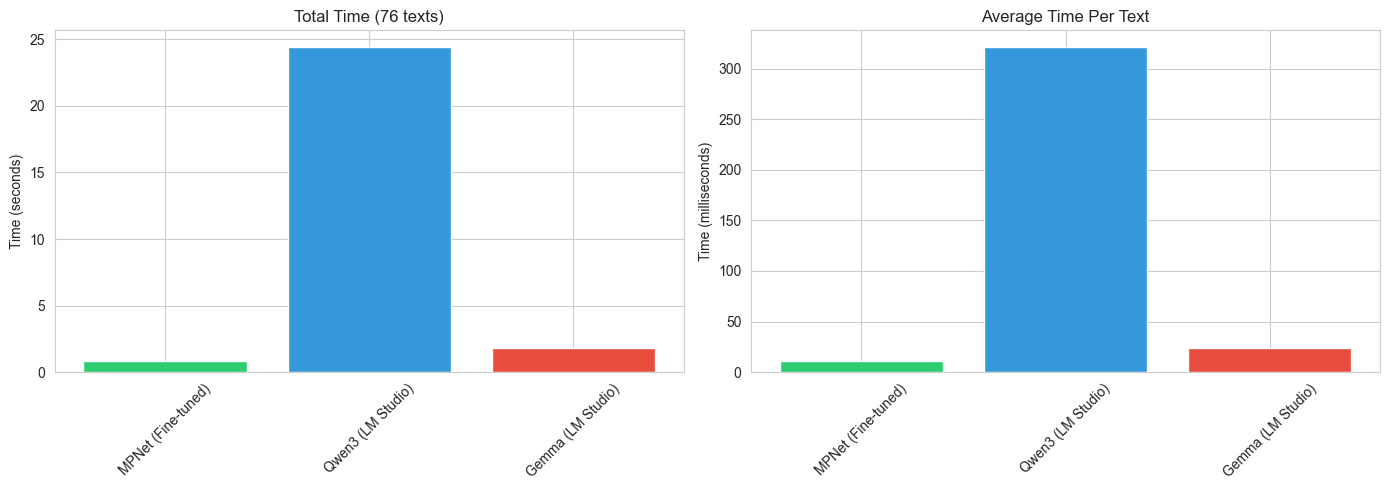


📊 Speed Summary:


,total_time,per_text,dimension
MPNet (Fine-tuned),0.85s,11.21ms,768.0
Qwen3 (LM Studio),24.45s,321.74ms,4096.0
Gemma (LM Studio),1.81s,23.84ms,768.0


In [6]:
# Create speed comparison chart
if speed_results:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    models = list(speed_results.keys())
    total_times = [speed_results[m]['total_time'] for m in models]
    per_text_times = [speed_results[m]['per_text'] * 1000 for m in models]  # Convert to ms
    
    # Total time
    ax1.bar(models, total_times, color=['#2ecc71', '#3498db', '#e74c3c'])
    ax1.set_ylabel('Time (seconds)')
    ax1.set_title(f'Total Time ({len(test_texts)} texts)')
    ax1.tick_params(axis='x', rotation=45)
    
    # Per text time
    ax2.bar(models, per_text_times, color=['#2ecc71', '#3498db', '#e74c3c'])
    ax2.set_ylabel('Time (milliseconds)')
    ax2.set_title('Average Time Per Text')
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary table
    print("\n📊 Speed Summary:")
    df_speed = pd.DataFrame(speed_results).T
    df_speed['total_time'] = df_speed['total_time'].apply(lambda x: f"{x:.2f}s")
    df_speed['per_text'] = df_speed['per_text'].apply(lambda x: f"{x*1000:.2f}ms")
    display(df_speed)

## 6. Benchmark: Similarity Search Accuracy

In [7]:
print("🎯 Benchmark 2: Similarity Search Accuracy\n")
print("="*60)
print("Testing how well each model identifies similar tickets (same category)\n")

def evaluate_similarity_accuracy(embeddings, metadata, model_name):
    """Evaluate how well the model finds tickets in the same category"""
    correct_retrievals = []
    
    for i in range(len(embeddings)):
        query_emb = embeddings[i:i+1]
        query_category = metadata[i]['category']
        
        # Calculate similarities
        similarities = cosine_similarity(query_emb, embeddings)[0]
        
        # Get top K (excluding self)
        top_indices = np.argsort(similarities)[::-1][1:CONFIG['top_k']+1]
        
        # Check how many are in the same category
        same_category = sum(1 for idx in top_indices if metadata[idx]['category'] == query_category)
        correct_retrievals.append(same_category / CONFIG['top_k'])
    
    avg_accuracy = np.mean(correct_retrievals)
    return avg_accuracy, correct_retrievals

accuracy_results = {}

# Evaluate each model
if finetuned_model:
    print("1. Fine-tuned MPNet...")
    mpnet_acc, mpnet_scores = evaluate_similarity_accuracy(mpnet_embeddings, test_metadata, 'MPNet')
    accuracy_results['MPNet (Fine-tuned)'] = {'accuracy': mpnet_acc, 'scores': mpnet_scores}
    print(f"   Accuracy: {mpnet_acc:.2%}")

if lm_client:
    print("\n2. Qwen3 Embedding...")
    qwen_acc, qwen_scores = evaluate_similarity_accuracy(qwen_embeddings, test_metadata, 'Qwen3')
    accuracy_results['Qwen3 (LM Studio)'] = {'accuracy': qwen_acc, 'scores': qwen_scores}
    print(f"   Accuracy: {qwen_acc:.2%}")
    
    print("\n3. Gemma Embedding...")
    gemma_acc, gemma_scores = evaluate_similarity_accuracy(gemma_embeddings, test_metadata, 'Gemma')
    accuracy_results['Gemma (LM Studio)'] = {'accuracy': gemma_acc, 'scores': gemma_scores}
    print(f"   Accuracy: {gemma_acc:.2%}")

print("\n" + "="*60)

🎯 Benchmark 2: Similarity Search Accuracy

Testing how well each model identifies similar tickets (same category)

1. Fine-tuned MPNet...
   Accuracy: 72.37%

2. Qwen3 Embedding...
   Accuracy: 43.16%

3. Gemma Embedding...
   Accuracy: 42.89%



### Accuracy Comparison Visualization

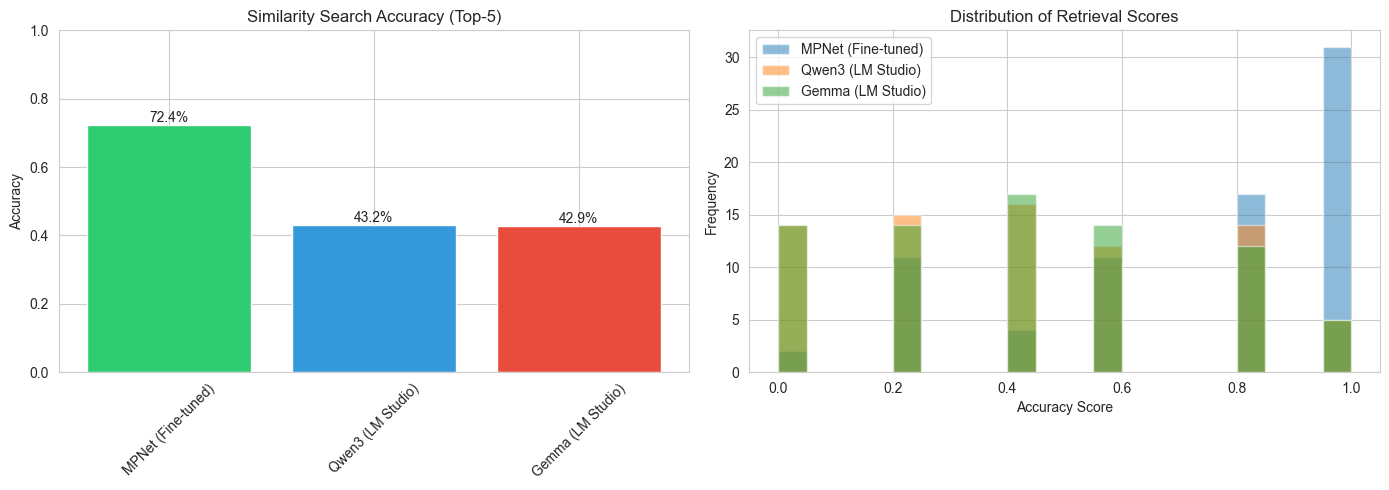


📊 Accuracy Summary:


,Model,Accuracy,Avg Score
0,MPNet (Fine-tuned),72.37%,0.724
1,Qwen3 (LM Studio),43.16%,0.432
2,Gemma (LM Studio),42.89%,0.429


In [8]:
if accuracy_results:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    models = list(accuracy_results.keys())
    accuracies = [accuracy_results[m]['accuracy'] for m in models]
    
    # Accuracy bar chart
    bars = ax1.bar(models, accuracies, color=['#2ecc71', '#3498db', '#e74c3c'])
    ax1.set_ylabel('Accuracy')
    ax1.set_title(f'Similarity Search Accuracy (Top-{CONFIG["top_k"]})')
    ax1.set_ylim([0, 1])
    ax1.tick_params(axis='x', rotation=45)
    
    # Add percentage labels on bars
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{acc:.1%}', ha='center', va='bottom')
    
    # Distribution of scores
    for model_name in models:
        scores = accuracy_results[model_name]['scores']
        ax2.hist(scores, bins=20, alpha=0.5, label=model_name)
    
    ax2.set_xlabel('Accuracy Score')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Distribution of Retrieval Scores')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Summary table
    print("\n📊 Accuracy Summary:")
    df_acc = pd.DataFrame({
        'Model': models,
        'Accuracy': [f"{acc:.2%}" for acc in accuracies],
        'Avg Score': [f"{np.mean(accuracy_results[m]['scores']):.3f}" for m in models]
    })
    display(df_acc)

## 7. Benchmark: Embedding Quality Metrics

In [9]:
print("📈 Benchmark 3: Embedding Quality Metrics\n")
print("="*60)

def calculate_embedding_metrics(embeddings, metadata):
    """Calculate various quality metrics for embeddings"""
    # Intra-category similarity (higher is better)
    category_groups = defaultdict(list)
    for i, meta in enumerate(metadata):
        category_groups[meta['category']].append(i)
    
    intra_similarities = []
    inter_similarities = []
    
    for category, indices in category_groups.items():
        if len(indices) < 2:
            continue
        
        # Intra-category: within same category
        cat_embeddings = embeddings[indices]
        cat_sim = cosine_similarity(cat_embeddings)
        # Get upper triangle (excluding diagonal)
        intra_sim = cat_sim[np.triu_indices_from(cat_sim, k=1)]
        intra_similarities.extend(intra_sim)
        
        # Inter-category: between different categories
        other_indices = [i for i in range(len(embeddings)) if i not in indices]
        if other_indices:
            other_embeddings = embeddings[other_indices]
            inter_sim = cosine_similarity(cat_embeddings, other_embeddings).flatten()
            inter_similarities.extend(inter_sim)
    
    return {
        'intra_category_sim': np.mean(intra_similarities),
        'inter_category_sim': np.mean(inter_similarities),
        'separation': np.mean(intra_similarities) - np.mean(inter_similarities),
        'intra_std': np.std(intra_similarities),
        'inter_std': np.std(inter_similarities)
    }

quality_results = {}

if finetuned_model:
    print("1. Fine-tuned MPNet...")
    mpnet_quality = calculate_embedding_metrics(mpnet_embeddings, test_metadata)
    quality_results['MPNet (Fine-tuned)'] = mpnet_quality
    print(f"   Intra-category similarity: {mpnet_quality['intra_category_sim']:.3f}")
    print(f"   Inter-category similarity: {mpnet_quality['inter_category_sim']:.3f}")
    print(f"   Separation: {mpnet_quality['separation']:.3f}")

if lm_client:
    print("\n2. Qwen3 Embedding...")
    qwen_quality = calculate_embedding_metrics(qwen_embeddings, test_metadata)
    quality_results['Qwen3 (LM Studio)'] = qwen_quality
    print(f"   Intra-category similarity: {qwen_quality['intra_category_sim']:.3f}")
    print(f"   Inter-category similarity: {qwen_quality['inter_category_sim']:.3f}")
    print(f"   Separation: {qwen_quality['separation']:.3f}")
    
    print("\n3. Gemma Embedding...")
    gemma_quality = calculate_embedding_metrics(gemma_embeddings, test_metadata)
    quality_results['Gemma (LM Studio)'] = gemma_quality
    print(f"   Intra-category similarity: {gemma_quality['intra_category_sim']:.3f}")
    print(f"   Inter-category similarity: {gemma_quality['inter_category_sim']:.3f}")
    print(f"   Separation: {gemma_quality['separation']:.3f}")

print("\n" + "="*60)

📈 Benchmark 3: Embedding Quality Metrics

1. Fine-tuned MPNet...
   Intra-category similarity: 0.387
   Inter-category similarity: 0.237
   Separation: 0.150

2. Qwen3 Embedding...
   Intra-category similarity: 0.456
   Inter-category similarity: 0.445
   Separation: 0.012

3. Gemma Embedding...
   Intra-category similarity: 0.417
   Inter-category similarity: 0.414
   Separation: 0.003



### Quality Metrics Visualization

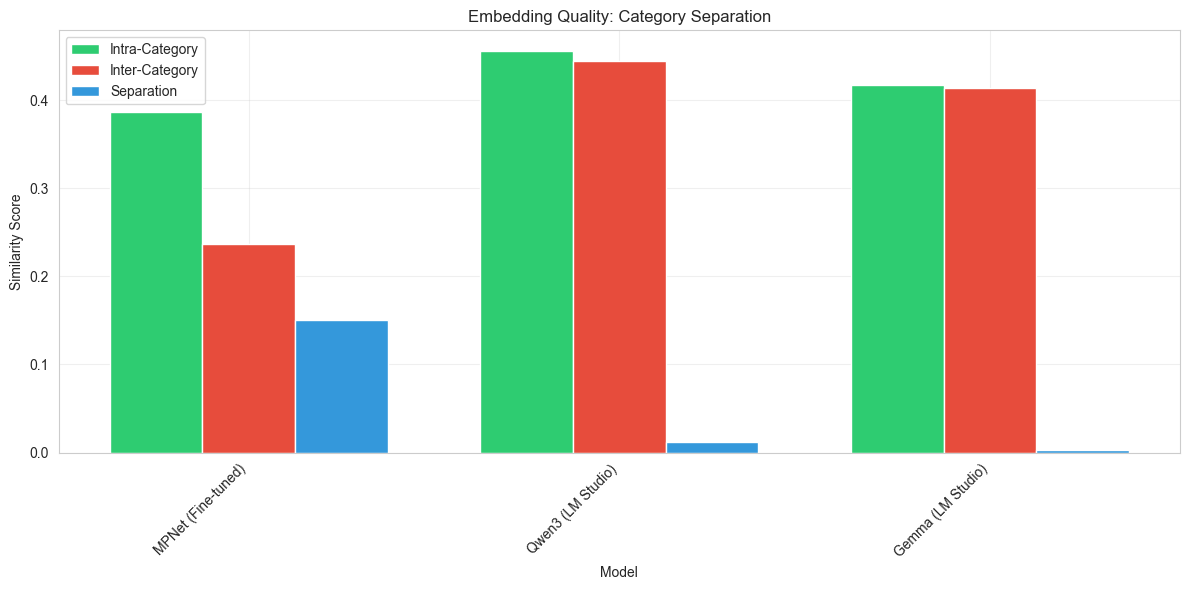


📊 Quality Metrics Summary:


,Intra-Category,Inter-Category,Separation
MPNet (Fine-tuned),0.387,0.237,0.150
Qwen3 (LM Studio),0.456,0.445,0.012
Gemma (LM Studio),0.417,0.414,0.003


In [10]:
if quality_results:
    models = list(quality_results.keys())
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    
    x = np.arange(len(models))
    width = 0.25
    
    intra_vals = [quality_results[m]['intra_category_sim'] for m in models]
    inter_vals = [quality_results[m]['inter_category_sim'] for m in models]
    sep_vals = [quality_results[m]['separation'] for m in models]
    
    ax.bar(x - width, intra_vals, width, label='Intra-Category', color='#2ecc71')
    ax.bar(x, inter_vals, width, label='Inter-Category', color='#e74c3c')
    ax.bar(x + width, sep_vals, width, label='Separation', color='#3498db')
    
    ax.set_xlabel('Model')
    ax.set_ylabel('Similarity Score')
    ax.set_title('Embedding Quality: Category Separation')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary table
    print("\n📊 Quality Metrics Summary:")
    df_quality = pd.DataFrame(quality_results).T
    df_quality = df_quality[['intra_category_sim', 'inter_category_sim', 'separation']]
    df_quality.columns = ['Intra-Category', 'Inter-Category', 'Separation']
    display(df_quality.round(3))

## 8. Final Comparison Summary

In [11]:
print("\n" + "="*60)
print("📊 FINAL COMPARISON SUMMARY")
print("="*60)

# Create comprehensive comparison table
comparison_data = []

for model_name in speed_results.keys():
    row = {
        'Model': model_name,
        'Dimension': speed_results[model_name]['dimension'],
        'Speed (ms/text)': f"{speed_results[model_name]['per_text']*1000:.2f}",
        'Accuracy': f"{accuracy_results[model_name]['accuracy']:.2%}" if model_name in accuracy_results else 'N/A',
        'Separation': f"{quality_results[model_name]['separation']:.3f}" if model_name in quality_results else 'N/A'
    }
    comparison_data.append(row)

df_comparison = pd.DataFrame(comparison_data)
print("\n")
display(df_comparison)

# Determine winner for each metric
print("\n🏆 Winners by Metric:")
print("="*60)

if speed_results:
    fastest_model = min(speed_results.items(), key=lambda x: x[1]['per_text'])[0]
    print(f"⚡ Fastest: {fastest_model}")

if accuracy_results:
    most_accurate = max(accuracy_results.items(), key=lambda x: x[1]['accuracy'])[0]
    print(f"🎯 Most Accurate: {most_accurate}")

if quality_results:
    best_separation = max(quality_results.items(), key=lambda x: x[1]['separation'])[0]
    print(f"📈 Best Separation: {best_separation}")

print("\n" + "="*60)
print("\n💡 Recommendations:")
print("="*60)
print("")
print("1. For SPEED: Choose the model with lowest ms/text")
print("2. For ACCURACY: Choose the model with highest accuracy")
print("3. For QUALITY: Choose the model with best separation")
print("4. BALANCED: Consider accuracy + separation with acceptable speed")
print("")


📊 FINAL COMPARISON SUMMARY




,Model,Dimension,Speed (ms/text),Accuracy,Separation
0,MPNet (Fine-tuned),768,11.21,72.37%,0.150
1,Qwen3 (LM Studio),4096,321.74,43.16%,0.012
2,Gemma (LM Studio),768,23.84,42.89%,0.003



🏆 Winners by Metric:
⚡ Fastest: MPNet (Fine-tuned)
🎯 Most Accurate: MPNet (Fine-tuned)
📈 Best Separation: MPNet (Fine-tuned)


💡 Recommendations:

1. For SPEED: Choose the model with lowest ms/text
2. For ACCURACY: Choose the model with highest accuracy
3. For QUALITY: Choose the model with best separation
4. BALANCED: Consider accuracy + separation with acceptable speed



## 9. Save Results

In [13]:
# Save results to JSON
def convert_numpy(obj):
    """Convert numpy types to Python native types for JSON serialization"""
    if isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {key: convert_numpy(value) for key, value in obj.items()}
    elif isinstance(obj, list):
        return [convert_numpy(item) for item in obj]
    return obj

results = {
    'timestamp': datetime.now().isoformat(),
    'config': {k: v for k, v in CONFIG.items() if not k.endswith('_model') or isinstance(v, str)},
    'num_test_samples': len(test_texts),
    'speed_results': convert_numpy(speed_results),
    'accuracy_results': {k: {'accuracy': float(v['accuracy'])} for k, v in accuracy_results.items()},
    'quality_results': convert_numpy(quality_results)
}

results_dir = '../performance_eval/results'
os.makedirs(results_dir, exist_ok=True)

results_file = os.path.join(results_dir, f'model_comparison_{datetime.now().strftime("%Y%m%d_%H%M%S")}.json')
with open(results_file, 'w') as f:
    json.dump(results, f, indent=2)

print(f"✅ Results saved to: {results_file}")

✅ Results saved to: ../performance_eval/results/model_comparison_20251113_032828.json
